# 2 — The realistic setup: a 1° global ocean with real weather and sea ice

[`01_pi_quickstart.ipynb`](01_pi_quickstart.ipynb) ran a toy ocean with a warm blob in it. This
notebook runs the **real thing**: the configuration used for actual science.

| | |
|---|---|
| **Mesh** | `CORE2` — the global ocean at ~1°, **126,858** points, 48 levels |
| **Initial state** | PHC 3.0 — observed winter temperature and salinity |
| **Forcing** | JRA55-do — real observed weather (wind, air temperature, rain, sunlight) |
| **Physics** | KPP vertical mixing, GM/Redi eddies, prognostic sea ice |
| **Hardware** | 1 GPU (fast) or a CPU (slower, but it works — the timings below are CPU) |
| **Data needed** | **yes** — see the next cell |

> ### ⚠️ This notebook needs input data
> Unlike notebook 1, this one cannot run from a bare `pip install`: it needs the CORE2 mesh, the PHC
> initial state, and the JRA55-do forcing. It is all published on Zenodo
> ([doi:10.5281/zenodo.21324319](https://doi.org/10.5281/zenodo.21324319)) — about 11 GB:
>
> ```bash
> python scripts/fetch_data.py --dest ~/fesom-data          # --mesh-only for just the 370 MB
> eval "$(python scripts/fetch_data.py --dest ~/fesom-data --print-env)"
> ```
>
> That sets the `FESOM_*` environment variables the next cell reads. On DKRZ/Levante the data is
> already on disk and the defaults below just work. See [`docs/DATA.md`](../docs/DATA.md).

In [1]:
import os
from pathlib import Path

# Mesh + cached initial state. Override with env vars to run this elsewhere.
MESH_DIR = Path(os.environ.get("FESOM_MESH_DIR", "../data/mesh_core2"))
IC_DIR   = Path(os.environ.get("FESOM_IC_DIR",   "../data/ic_core2"))

# The forcing files (JRA55-do, sea-surface-salinity restoring, runoff, chlorophyll) are resolved
# by the library, in this order:  explicit argument  >  environment variable  >  Levante default.
from fesom_jax import paths

print("mesh   :", MESH_DIR, "" if MESH_DIR.is_dir() else "  <-- MISSING")
print("IC     :", IC_DIR,   "" if IC_DIR.is_dir()   else "  <-- MISSING")
for name in ("jra_dir", "sss_path", "runoff_path", "chl_path"):
    p = Path(paths.resolve(name))
    print(f"{name:<12}:", p, "" if p.exists() else "  <-- MISSING")

if not (MESH_DIR.is_dir() and IC_DIR.is_dir()):
    raise SystemExit("Input data missing — see docs/DATA.md. (Notebook 1 needs none of this.)")

mesh   : ../data/mesh_core2 
IC     : ../data/ic_core2 
jra_dir     : /pool/data/AWICM/FESOM2/FORCING/JRA55-do-v1.4.0 
sss_path    : /pool/data/AWICM/FESOM2/FORCING/JRA55-do-v1.4.0/PHC2_salx.nc 
runoff_path : /pool/data/AWICM/FESOM2/FORCING/JRA55-do-v1.4.0/CORE2_runoff.nc 
chl_path    : /pool/data/AWICM/FESOM2/FORCING/Sweeney/Sweeney_2005.nc 


---
## The mesh and the observed initial state

Same `load_mesh` as before, just a bigger mesh — and this time the initial temperature and salinity
are not invented, they are **observations** (the PHC 3.0 winter climatology).

In [2]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from fesom_jax.mesh import load_mesh
from fesom_jax.phc_ic import core2_initial_state

mesh = load_mesh(MESH_DIR)
print(f"nodes {mesh.nod2D:,} | triangles {mesh.elem2D:,} | levels {mesh.nl}")

state0 = core2_initial_state(mesh, IC_DIR)      # observed T/S, ocean at rest
sst0 = state0.T[:, 0]

nodes 126,858 | triangles 244,659 | levels 48


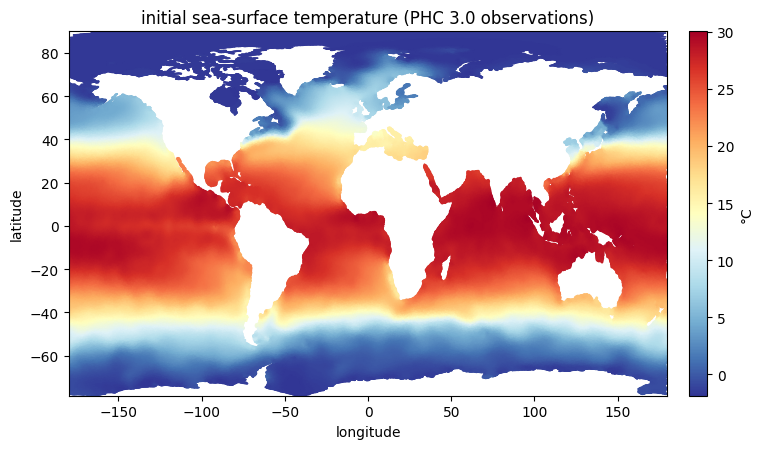

In [3]:
lon, lat = np.degrees(np.asarray(mesh.geo_coord_nod2D)).T
tris = np.asarray(mesh.elem_nodes)
wrap = np.abs(lon[tris] - lon[tris][:, [0]]).max(axis=1) > 180
triang = mtri.Triangulation(lon, lat, tris, mask=wrap)

def plot_field(values, title, cmap="viridis", units="", **kw):
    fig, ax = plt.subplots(figsize=(11, 4.6))
    tpc = ax.tripcolor(triang, np.asarray(values), cmap=cmap, shading="gouraud", **kw)
    fig.colorbar(tpc, ax=ax, label=units, pad=0.02)
    # limits come from the mesh: CORE2 is -180..180, but the pi mesh is 0..360
    ax.set(title=title, xlabel="longitude", ylabel="latitude",
           xlim=(lon.min(), lon.max()), ylim=(lat.min(), lat.max()))
    ax.set_aspect(1.3)
    plt.tight_layout()
    plt.show()

plot_field(sst0, "initial sea-surface temperature (PHC 3.0 observations)",
           cmap="RdYlBu_r", units="°C")

That is the ocean as it actually is: warm equator, cold poles, the Gulf Stream and Kuroshio carrying
heat polewards, and freezing water at both ends.

---
## The forcing — real weather

An ocean-only model does not simulate the atmosphere; it is *driven* by it. `build_core_forcing`
opens the JRA55-do reanalysis (observed weather, 3-hourly, since 1958) and interpolates it onto the
mesh. We start on **1 January 1958**.

JRA55-do forcing ready in 2.1 s
date: (1958, 1, 0.0, 1)


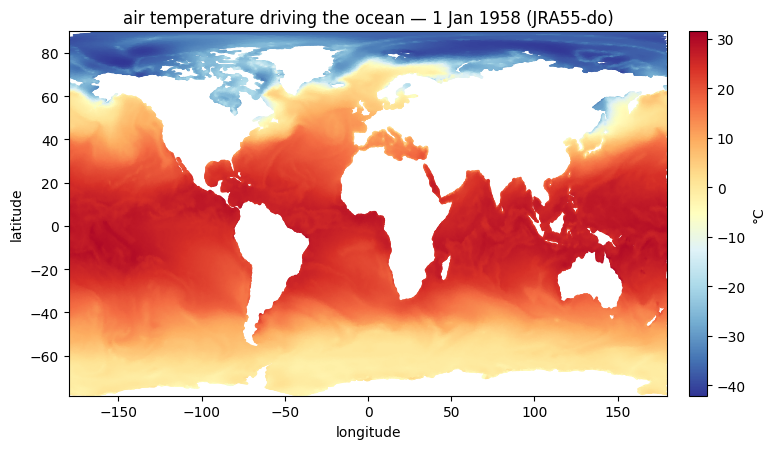

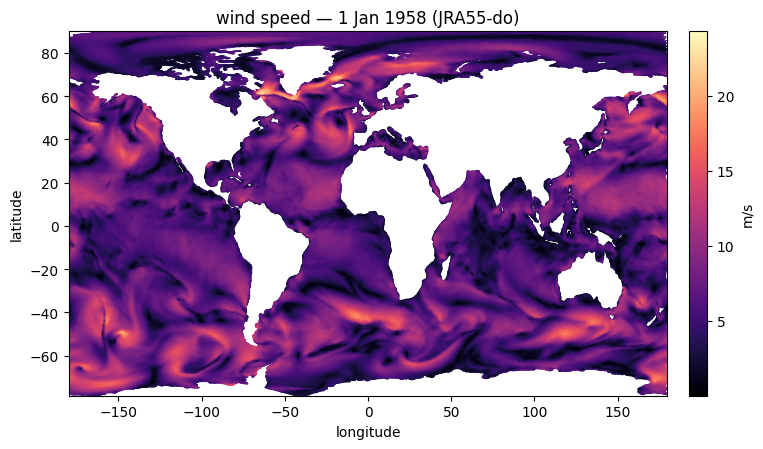

In [4]:
from fesom_jax import surface_forcing, ice

YEAR, DT = 1958, 1800.0                       # CORE2 runs at a 30-minute timestep

t0 = time.time()
forcing = surface_forcing.build_surface_forcing(mesh, YEAR, sst_ic=sst0)
print(f"JRA55-do forcing ready in {time.time() - t0:.1f} s")

# the weather at the first timestep
date0 = surface_forcing.dates_for_steps(YEAR, DT, 1)[0]
sf0 = forcing.step_forcing(*date0)
print("date:", date0)

plot_field(sf0.Tair, "air temperature driving the ocean — 1 Jan 1958 (JRA55-do)",
           cmap="RdYlBu_r", units="°C")
plot_field(np.hypot(np.asarray(sf0.u_air), np.asarray(sf0.v_air)),
           "wind speed — 1 Jan 1958 (JRA55-do)", cmap="magma", units="m/s")

---
## Full physics, and sea ice

Now switch on the parameterizations that a realistic run needs. Each is a config object; passing
`None` instead turns that piece off.

- **KPP** — how the wind and surface cooling mix the upper ocean.
- **GM / Redi** — the stirring done by eddies too small for a 1° mesh to resolve.
- **Sea ice** — a full prognostic model: ice grows, melts, and is pushed around by wind and currents.

`seed_ice` puts ice where the observed water is already at freezing point.

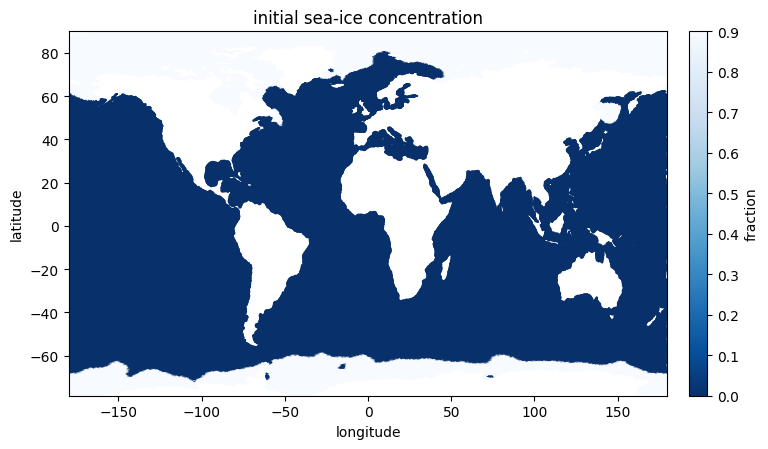

In [5]:
from fesom_jax.kpp import KppConfig
from fesom_jax.gm import GMConfig
from fesom_jax.ice import IceConfig
from fesom_jax.ssh import build_ssh_operator
from fesom_jax.integrate import integrate

state0 = ice.seed_ice(state0, mesh, sst0)          # cold-start the sea ice from observed SST
op = build_ssh_operator(mesh, dt=DT)
stress = jnp.zeros((mesh.elem2D, 2))

plot_field(state0.a_ice, "initial sea-ice concentration", cmap="Blues_r", units="fraction")

### Run one day of the global ocean

48 steps at 30 minutes each. On a GPU this is seconds; on a CPU expect a few minutes, most of it
JAX compiling the timestep (which then gets reused).

In [6]:
N_STEPS = 48                                        # = 1 day at dt = 1800 s

dates = surface_forcing.dates_for_steps(YEAR, DT, N_STEPS)
step_forcings = forcing.stack(dates)                # the weather for each step

t0 = time.time()
state = integrate(state0, mesh, op, stress, n_steps=N_STEPS, dt=DT,
                  step_forcings=step_forcings, forcing_static=forcing.static,
                  kpp_cfg=KppConfig(), gm_cfg=GMConfig(), ice_cfg=IceConfig())
state.T.block_until_ready()
print(f"{N_STEPS} steps (1 ocean-day) in {time.time() - t0:.1f} s  (includes one-off compilation)")

48 steps (1 ocean-day) in 376.7 s  (includes one-off compilation)


In [7]:
from fesom_jax.diagnostics import state_diagnostics, format_diagnostics

print(format_diagnostics(
    state_diagnostics(state, fields=["T", "S", "uv", "eta_n", "a_ice", "m_ice"]),
    label="CORE2 after 1 day"))

[diagnostics CORE2 after 1 day] FINITE  n_nonfinite=0
  max|uv|=1.176  max|uvnode|=1.037  max|w|=0.031  max|eta|=1.412
  T[-2.053,29.89]  S[0,41.11]  a_ice_max=1  m_ice_max=2.254


The numbers are physical: temperature between the freezing point (−1.8 °C) and ~30 °C in the tropics,
sea ice covering most of the polar oceans, currents below 1 m/s. Nothing has blown up.

### What changed in a day

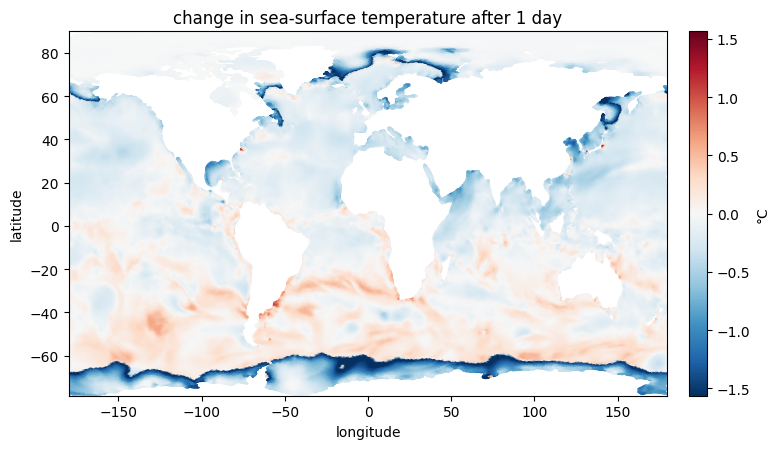

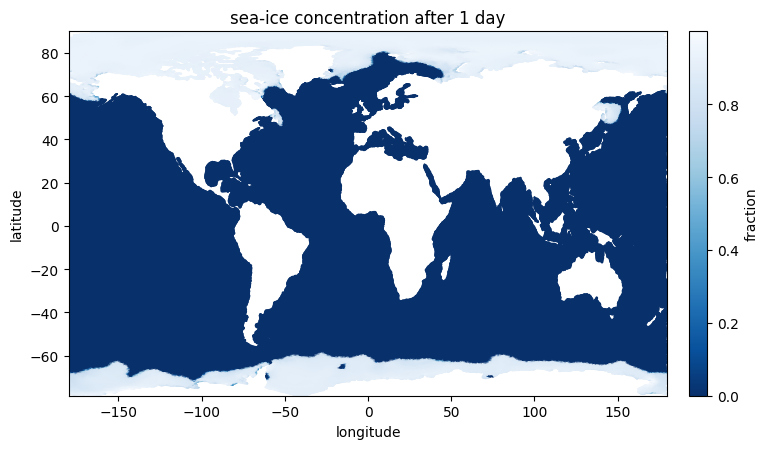

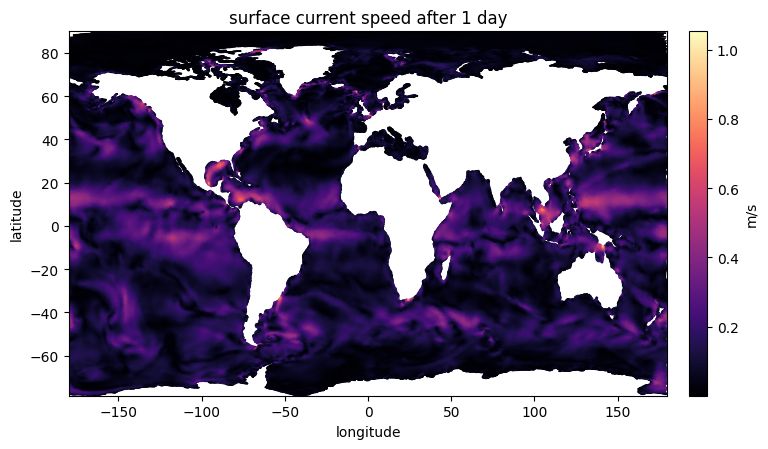

In [8]:
dSST = np.asarray(state.T[:, 0]) - np.asarray(sst0)
lim = float(np.percentile(np.abs(dSST), 99))

plot_field(dSST, "change in sea-surface temperature after 1 day",
           cmap="RdBu_r", units="°C", vmin=-lim, vmax=lim)
plot_field(state.a_ice, "sea-ice concentration after 1 day", cmap="Blues_r", units="fraction")

speed = np.linalg.norm(np.asarray(state.uvnode[:, 0, :]), axis=-1)
plot_field(speed, "surface current speed after 1 day", cmap="magma", units="m/s")

In a single day the ocean responds to the weather: it cools where cold air blows over it, warms
under the sun, and the currents begin to spin up. Run this for decades and you get a full ocean
hindcast — which is exactly what the next section is for.

---
# Running it for real

A one-day run in a notebook is a demo. Real runs are years to decades long, need restarts, and often
span many GPUs. You do **not** drive those from a notebook — you drive them from a **single YAML
config file**.

In [9]:
from fesom_jax.run_config import load_yaml

cfg = load_yaml("../configs/core2_full.yaml")
print("dt        :", cfg.dt)
print("mesh      :", cfg.mesh)
print("vertical  :", "TKE" if cfg.tke is not None else "KPP")
print("eddies GM :", "on" if cfg.gm is not None else "off")
print("sea ice   :", "on (mEVP)" if cfg.ice is not None else "off")
print("duration  :", cfg.duration)

dt        : 1800.0
mesh      : data/mesh_core2
vertical  : TKE
eddies GM : on
sea ice   : on (mEVP)
duration  : 10yr


The schema is deliberately blunt: **`null` = that physics is off, `{}` = on with defaults, a mapping
= on with overrides.** An absent key takes the default, and an unknown key is an error rather than a
silent typo.

### Time-chunking and restarts

A multi-year run cannot hold every timestep's weather in memory, so the driver splits the run into
chunks, and can change the timestep partway through (a "dt ramp" — start slow and safe, then speed
up once the model has settled).

In [10]:
from fesom_jax.run import parse_duration, plan_chunks

n = parse_duration("2d", cfg.dt)                    # durations: "10step", "5d", "3mo", "2yr"
print(f'"2d" at dt={cfg.dt:.0f}s = {n} steps\n')

for chunk in plan_chunks(n, chunk_steps=48, start_step=0, dt_ramp=cfg.dt_ramp, dt=cfg.dt):
    print(" ", chunk)

"2d" at dt=1800s = 96 steps

  Chunk(start=0, count=48, dt=1800.0, bootstrap_ab2=True)
  Chunk(start=48, count=48, dt=1800.0, bootstrap_ab2=False)


### Streaming statistics

You rarely want every timestep saved — you want the time-mean state, and the variability. `OnlineStats`
accumulates both **as the model runs** (Welford's algorithm), so a 60-year mean costs no extra memory
and the eddy kinetic energy comes out for free.

In [11]:
from fesom_jax.zarr_output import OnlineStats, eke_from_stats

rng = np.random.default_rng(0)
stats = None
for _ in range(50):                                  # pretend: 50 steps of surface velocity
    uv = {"uv": rng.standard_normal((100, 1, 2))}
    stats = OnlineStats.init(uv) if stats is None else stats.update(uv)

print("accumulated    :", int(stats.count), "steps")
print("time-mean shape:", stats.mean_dict()["uv"].shape)
print("mean EKE       :", f"{float(eke_from_stats(stats).mean()):.3f} m2/s2")

accumulated    : 49 steps
time-mean shape: (100, 1, 2)


mean EKE       : 0.977 m2/s2


### Launching a long run

One command runs a segment and writes a **portable restart** — portable meaning you can save on 64
GPUs and resume on 8, or vice versa.

```bash
# one segment, cold start
python scripts/run_from_config.py configs/core2_full.yaml --steps 480 --restart-out runs/core2/seg0

# resume it and keep going (on any number of devices)
python scripts/run_from_config.py configs/core2_full.yaml \
       --restart-in runs/core2/seg0 --steps 480 --restart-out runs/core2/seg1

# a multi-year campaign = a chain of SLURM jobs
scripts/chain_submit.sh configs/core2_full.yaml 12 4800 /work/.../runs/core2
```

Output is written straight to **Zarr**, one shard per GPU in parallel, so nothing has to be gathered
onto a single rank. Full details in [`docs/USER_GUIDE.md`](../docs/USER_GUIDE.md).

---
## Gradients at this scale

Everything from notebook 1 still works here — `jax.grad` through the full 1° model with sea ice — but
two limits are worth knowing before you rely on it:

1. **Gradients run on one GPU.** A bug in JAX's multi-GPU communication makes the *sharded* backward
   pass wrong (the forward is fine). See [`docs/JAX_RAGGED_A2A_BUG.md`](../docs/JAX_RAGGED_A2A_BUG.md).
2. **The ocean is chaotic**, so a gradient is only meaningful over hours to days. Beyond roughly a
   day it grows exponentially and becomes noise. For slow, climate-scale questions there are other
   tools (ensemble-averaged adjoints, and gradient-free ensemble methods).

Both are covered honestly in the README under
[Limitations](../README.md#limitations--what-it-can-and-cant-do) — read it before designing an
experiment around the adjoint.

## Where to go next

- **[`docs/USER_GUIDE.md`](../docs/USER_GUIDE.md)** — the full YAML schema, restarts, multi-GPU.
- **[`docs/DATA.md`](../docs/DATA.md)** — the input datasets and how to point the model at them.
- **[`README.md`](../README.md)** — performance, and what the model can and cannot do.